1. Create API call to extract gov data
Link to Austender Website: https://www.tenders.gov.au/Reports/CnPublishedForm


API Reference Data: https://github.com/austender/austender-ocds-api/tree/master

In [29]:
#Extracting the data from the API 

import requests
import json

start_date = '2026-06-01T00:00:00Z'
end_date = '2026-06-01T23:48:48Z'

url = f'https://api.tenders.gov.au/ocds/findByDates/contractPublished/{start_date}/{end_date}'

response = requests.get(url)
data = response.json()


In [39]:
#Create a flat file for the dataframe

import pandas as pd
rows = []

for release in data['releases']:
    ocid = release.get('ocid')
    tender = release.get('tender',{})

    procurement_method = tender.get('procurementMethod')

    # Parties (supplier + procuring entity)
    parties = release.get('parties',[])

    # Awards (supplier info lives here too)
    awards = release.get('awards',[])

    # Contracts (value, UNSPSC, dates)
    contracts = release.get('contracts',[])

    for contract in contracts:
        contract_id = contract.get('id')

        rows.append({
            'ocid':ocid,
            'procurement_method':procurement_method,
            'contract_id':contract_id
        })





print(rows)

[{'ocid': 'prod-44a884eac7304063a538d0179d9deb0f', 'procurement_method': 'limited', 'contract_id': 'CN4245783'}, {'ocid': 'prod-d283420127094567a1c74e7d0d974a29', 'procurement_method': 'open', 'contract_id': 'CN4245482'}, {'ocid': 'prod-2feb9dd0e8a94db5a1897260fa6d97a3', 'procurement_method': 'open', 'contract_id': 'CN4245757'}, {'ocid': 'prod-615f4cec5775466ea755508b359f5cfd', 'procurement_method': 'open', 'contract_id': 'CN4245758'}, {'ocid': 'prod-de04bd358e5b499ba29db7a6469d74ed', 'procurement_method': 'open', 'contract_id': 'CN4245755'}, {'ocid': 'prod-988958069a6041d1b357056f76dc9140', 'procurement_method': 'limited', 'contract_id': 'CN4245756'}, {'ocid': 'prod-d35f6a3b63844e3b85417b7aed0afa22', 'procurement_method': 'limited', 'contract_id': 'CN4245752'}, {'ocid': 'prod-f7bae6c4c2af4fe6a2cf22163080e918', 'procurement_method': 'limited', 'contract_id': 'CN4245753'}, {'ocid': 'prod-352ad426caa14dacb0d9b0192c1c84b7', 'procurement_method': 'open', 'contract_id': 'CN4245754'}, {'ocid

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

f_path = r'..\data\AusTender-Contract-Notice-Published_20260625_204650.xlsx'

df = pd.read_excel(f_path,header=17)

In [38]:
df['Value (AUD)'] = df['Value (AUD)'].round(0).astype(int)

In [39]:
df

,Agency,CN ID,SON ID,Supplier Name,Supplier ABN,Description,Category,Agency Ref. ID,Publish Date,Start Date,End Date,Value (AUD)
0,Australian Centre for International Agricultur...,CN4253780,NaN,Grace Records Management Aust Pty Ltd,93097110257,Records Management Storage,Management information systems MIS,C005737,2026-06-25 13:38:40,2026-07-01,2029-06-30,26400
1,Australian Centre for International Agricultur...,CN4253972,SON4228134,DATA#3 Limited,31010545267,VSA6 - Microsoft Licensing Software,Components for information technology or broad...,C005798,2026-06-25 14:57:33,2026-07-01,2031-06-30,650152
2,Australian Centre for International Agricultur...,CN4253974,SON4228134,DATA#3 Limited,31010545267,VSA6 - CRM Microsoft Licensing Software,Components for information technology or broad...,C005799,2026-06-25 15:15:10,2026-07-01,2031-06-30,169492
3,Australian Criminal Intelligence Commission,CN4253989,SON4102906,Myndworks trading as SKILL'D People.,95129394010,Contracted Services,Temporary personnel services,0000004195,2026-06-25 15:47:19,2026-07-01,2027-06-30,355417
4,Australian Criminal Intelligence Commission,CN4254039,SON4102906,Myndworks trading as SKILL'D People.,95129394010,Contracted Services,Temporary personnel services,0000004196,2026-06-25 19:57:37,2026-07-01,2027-06-30,335107
...,...,...,...,...,...,...,...,...,...,...,...,...
342,Office of the Director of Public Prosecutions,CN4253975,NaN,Vikrant Chaudhri,29235335988,Marine expert report,Legal services,G003259,2026-06-25 15:22:35,2026-06-10,2026-07-11,25000
343,Office of the Director of Public Prosecutions,CN4253991,NaN,Clare O'Connor,56181395947,Engagement of prosecution counsel,Legal services,N009417,2026-06-25 16:05:31,2026-05-27,2036-05-26,10000
344,Office of the Director of Public Prosecutions,CN4254032,NaN,Duncan James Berents,54822497228,Engagement of prosecution counsel,Legal services,N009510,2026-06-25 16:56:01,2026-06-25,2036-06-24,48400
345,Office of the Director of Public Prosecutions,CN4254035,SON3965020,Hudson Global Resources (Aust) Pty Limited,21002888762,LSO Perth,Temporary personnel services,G003263,2026-06-25 17:16:52,2026-07-03,2026-10-02,34359


In [40]:
agency_df = df.groupby('Agency').agg({'Value (AUD)':'sum'})
agency_df

,Value (AUD)
Agency,
Australian Centre for International Agricultural Research,846044
Australian Criminal Intelligence Commission,690524
Australian Maritime Safety Authority,617678
Australian Pesticides and Veterinary Medicines Authority,9434488
"Department of Climate Change, Energy, the Environment and Water",2252951
Department of Defence,54191722
Department of Education,18545163
Department of Employment and Workplace Relations,1469813
Department of Finance,2160261


In [42]:
supplier_df = df.groupby('Supplier Name').agg({'Value (AUD)':'sum'})
supplier_df

,Value (AUD)
Supplier Name,
"A.M.T. MARICAN LTD.,PART.",90406
AEROBASE GROUP INC,69763
AGILENT TECHNOLOGIES AUSTRALIA PTY LTD,32992
APOLLO TECHNOLOGY PTY LTD,15726
APRICOT ZEBRA PTY LTD,75075
...,...
YMCA Australia,21802
Zenith Media; a division of Publicis Media Australia Pty Ltd,189000000
[AUD] Scantechnics Pty Ltd,15322


In [51]:
category_df = df.groupby(['Category','Supplier Name'], as_index=False).agg(
    total = ('Value (AUD)','sum'),
    average = ('Value (AUD)','mean'))
category_df

,Category,Supplier Name,total,average
0,Adhesives and sealants,MILSPEC SERVICES PTY LIMITED,13640,13640.0
1,Advertising,Zenith Media; a division of Publicis Media Aus...,189000000,189000000.0
2,Aerospace systems and components and equipment,MILSPEC SERVICES PTY LIMITED,55974,27987.0
3,Air transportation support systems and equipment,EUROCONTROLORGANISATION EUROPEENNE POUR LA SEC...,16332,16332.0
4,Aircraft equipment,MILSPEC SERVICES PTY LIMITED,10003,10003.0
...,...,...,...,...
250,Vehicle maintenance and repair services,HAULMARK TRAILERS (AUSTRALIA) PTY LTD,63117,31558.5
251,Vehicle maintenance and repair services,R.G.M. MAINTENANCE PTY LTD,67911,33955.5
252,Vehicle maintenance and repair services,RHEINMETALL MAN MILITARY VEHICLES AUSTRALIA PT...,126559,63279.5
253,War vehicles,THALES AUSTRALIA,138640,69320.0


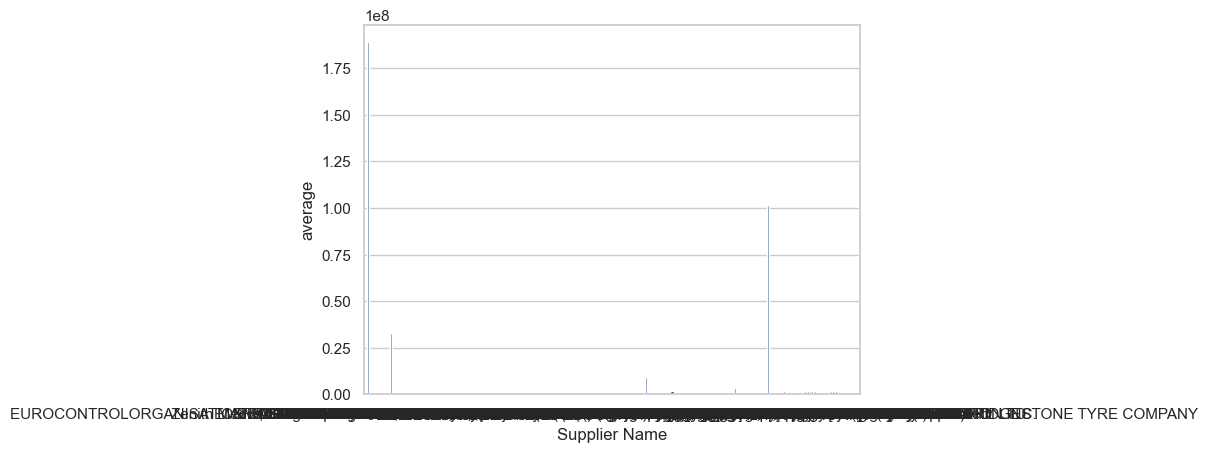

In [57]:
sns.barplot(data=category_df,x='Supplier Name',y='average')
plt.show()